<a href="https://colab.research.google.com/github/Godenzo0n/ml-train/blob/develop/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

titanic_path = kagglehub.competition_download('titanic')

print('Data source import complete.')


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



##  2. Получение данных (Import data)

In [ ]:
df_train = pd.read_csv('/kaggle/input/titanic/train.csv', index_col='PassengerId')
df_test = pd.read_csv('/kaggle/input/titanic/test.csv', index_col='PassengerId')


## 3. Исследовательский анализ данных (EDA)

In [ ]:
df_train.shape # количество строк и количество столбцов фрейма

(891, 11)

In [ ]:
df_train.sample(5) # выведет 5 случайных объектов таблицы
# а можно df_train.head() и/или df_train.tail() для просмотра некоторого количества данных таблицы c начала и/или с конца

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
148,0,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.3750,NaN,S
119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C
115,0,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
737,0,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.3750,NaN,S


### 3.1. Описание признаков

In [ ]:
numerical_columns = df_train.select_dtypes(exclude='object').columns.tolist() # список количественные столбцы
numerical_columns

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [ ]:
df_train[numerical_columns].describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
categorial_columns = df_train.select_dtypes(include='object').columns.tolist() # список категориальные столбцы
categorial_columns

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [ ]:
# посмотреть какие есть значения в категориальных столбцах
def cat_value_counts(df, columns_list):
    for name_column in columns_list:
        if name_column != 'Name' and name_column != 'Ticket':
            print(df[name_column].value_counts())
            print()


print('Тренировочный:')
cat_value_counts(df_train, categorial_columns)
print('Тестовый:')
cat_value_counts(df_test, categorial_columns)

Тренировочный:
Sex
male      577
female    314
Name: count, dtype: int64

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Тестовый:
Sex
male      266
female    152
Name: count, dtype: int64

Cabin
B57 B59 B63 B66    3
B45                2
C89                2
C55 C57            2
A34                2
                  ..
E52                1
D30                1
E31                1
C62 C64            1
C105               1
Name: count, Length: 76, dtype: int64

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64



Посмотрим

In [ ]:
import seaborn as sns

<Axes: xlabel='Sex', ylabel='Survived'>

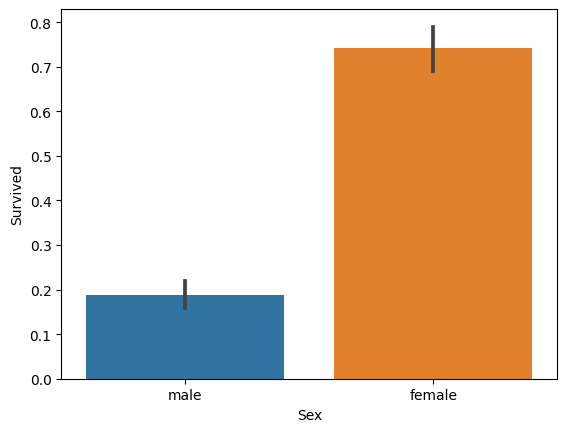

In [ ]:
sns.barplot(x='Sex', y='Survived', data=df_train)

<Axes: xlabel='Pclass', ylabel='Survived'>

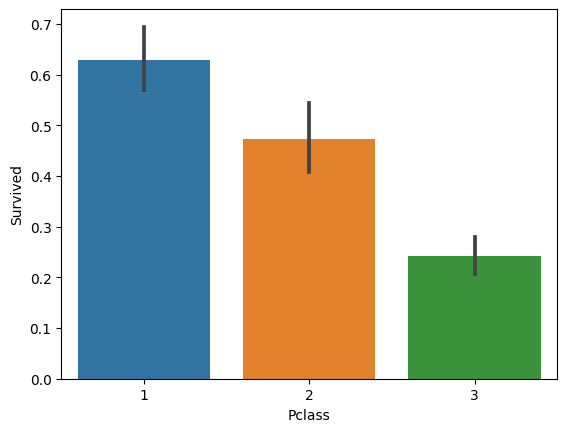

In [ ]:
sns.barplot(x='Pclass', y='Survived', data=df_train)


## 4. Обработка данных

### 4.1. Очистка от пропущенных значений

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [ ]:
df_train['Age'] = df_train['Age'].fillna(-1)
df_test['Age'] = df_test['Age'].fillna(-1)

In [ ]:
# заполним "Посадку" как "S" (Southampthon), т.к. там село большинство пассажиров (мода)
df_train['Embarked'] = df_train['Embarked'].fillna('S')
df_test['Embarked'] = df_test['Embarked'].fillna('S')

In [ ]:
# много пропусков. Просто удалю весь столбец (._.)
df_train = df_train.drop('Cabin', axis=1)
df_test = df_test.drop('Cabin', axis=1)


In [ ]:
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].mean())

In [ ]:
print('Пропусков в train:')
print(df_train.isnull().sum().sum())
print('Пропусков в test:')
print(df_test.isnull().sum().sum())

Пропусков в train:
0
Пропусков в test:
0


### 4.2. Обработка категориальных фич
Проблема - алгоритмы не умеют работать не с числовыми данными. Их надо сделать числовыми для создания модели

In [ ]:
df_train['Sex'] = df_train['Sex'].apply(lambda x: 0 if x=='male' else 1)
df_test['Sex'] = df_test['Sex'].apply(lambda x: 0 if x=='male' else 1)

In [ ]:
def unique_values_dict():
    new_dict = {}
    for index in range(len(unique_values_list)):
        new_dict[unique_values_list[index]] = index + 1
    return new_dict

In [ ]:
unique_values_list = df_train['Embarked'].unique().tolist()
unique_values_dict = unique_values_dict()

df_train['Embarked'] = df_train['Embarked'].map(unique_values_dict)
df_test['Embarked'] = df_test['Embarked'].map(unique_values_dict)


In [ ]:
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [ ]:
df_train['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [ ]:
def create_unique_dict(df):
    unique_values = df['Title'].unique().tolist()
    new_dict = {}
    for i in range(len(unique_values)):
        new_dict[unique_values[i]] = i + 1
    return new_dict

In [ ]:
unique_values_dict = create_unique_dict(df_train)
df_train['Title'] = df_train['Title'].map(unique_values_dict)
df_test['Title'] = df_test['Title'].map(unique_values_dict)


In [ ]:
df_train = df_train.drop(['Name','Ticket'], axis=1)
df_test = df_test.drop(['Name','Ticket'], axis=1)

In [ ]:
df_test = df_test.fillna('0') # одно значение Title
print('Пустые значения test:')
print(df_test.isnull().sum().sum())
print(f'Размер тестовой: {df_test.shape}, Размер тренировочной: {df_train.shape}')

Пустые значения test:
0
Размер тестовой: (418, 8), Размер тренировочной: (891, 9)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f'Размер матрицы объект-признаков X: {X_train.shape}, вектор ответов y: {y_train.shape}')

Размер матрицы объект-признаков X: (712, 8), вектор ответов y: (712,)


# 5. Выбор модели

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier

In [ ]:
def model_score(df_score, model_name, y_hat, y_true):
    df_score.loc[len(df_score) + 1] = [
        model_name.__name__,
        accuracy_score(y_hat, y_true),
        recall_score(y_hat, y_true),
        precision_score(y_hat, y_true),
        f1_score(y_hat, y_true),
    ]
    return df_score

In [ ]:
def model(models_list, X_train, X_test, y_train, y_test):
    df_model_score = pd.DataFrame({
        'model_name':[],
        'accuracy':[],
        'recall':[],
        'precision':[],
        'f1':[]
    })

    for model_class in models_list:
        model = model_class()
        model.fit(X_train, y_train)
        y_hat = model.predict(X_test)
        model_score(df_model_score, model_class, y_hat, y_test)

    print(df_model_score)

In [ ]:
model_list = [LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVC, CatBoostClassifier]
model(model_list, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Learning rate set to 0.008911
0:	learn: 0.6870696	total: 54.6ms	remaining: 54.5s
1:	learn: 0.6811546	total: 55.9ms	remaining: 27.9s
2:	learn: 0.6753868	total: 57.1ms	remaining: 19s
3:	learn: 0.6697287	total: 58.2ms	remaining: 14.5s
4:	learn: 0.6658996	total: 59.1ms	remaining: 11.8s
5:	learn: 0.6611587	total: 60.2ms	remaining: 9.96s
6:	learn: 0.6552405	total: 61.3ms	remaining: 8.69s
7:	learn: 0.6499082	total: 62.6ms	remaining: 7.76s
8:	learn: 0.6449527	total: 63.7ms	remaining: 7.01s
9:	learn: 0.6400130	total: 64.7ms	remaining: 6.41s
10:	learn: 0.6347958	total: 65.8ms	remaining: 5.92s
11:	learn: 0.6295913	total: 66.9ms	remaining: 5.51s
12:	learn: 0.6245980	total: 68.1ms	remaining: 5.17s
13:	learn: 0.6194997	total: 69.2ms	remaining: 4.87s
14:	learn: 0.6150287	total: 70.3ms	remaining: 4.61s
15:	learn: 0.6112176	total: 71ms	remaining: 4.36s
16:	learn: 0.6073800	total: 72.1ms	remaining: 4.17s
17:	learn: 0.6032090	total: 73.2ms	remaining: 3.99s
18:	learn: 0.5989291	total: 74.2ms	remaining: 3.

rf - лучший из представленных моделей

In [ ]:
final_model = RandomForestClassifier(n_estimator=500)
final_model.fit(X_train, y_train)
print(accuracy())
y_hat = final_model.predict(df_test)

In [ ]:
submit = pd.DataFrame(columns=['PassengerId','Survived'])
submit['PassengerId'] = df_test.index
submit['Survived'] = y_hat
submit.to_csv('submission.csv',index=False)

In [ ]:
submit

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
